# Лабораторна робота №4
## Тема: Методи класифікації. Дерева рішень у Python
**Дисципліна:** Інтелектуальний аналіз даних (ІАД)  
**Студент:** Багрій-Белз Андрій, група КН-2327Б  

### Мета роботи
Дослідити алгоритми побудови класифікаційних дерев рішень (`DecisionTreeClassifier`) за допомогою бібліотеки `scikit-learn`, вивчити критерій ентропії, оцінити схильність глибоких дерев до перенавчання та реалізувати підбір оптимального гіперпараметра регуляризації (`min_samples_split`) через 5-кратну крос-валідацію.

### 1. Імпорт бібліотек та налаштування середовища
Підключаємо модулі для аналізу даних (`pandas`, `numpy`), побудови моделей машинного навчання (`sklearn`) та візуалізації (`matplotlib`, `seaborn`).

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# Налаштування стилю візуалізації
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})
print('Усі необхідні бібліотеки успішно імпортовано.')

Усі необхідні бібліотеки успішно імпортовано.


### 2. Завантаження та первинний аналіз медичних даних
Для аналізу використовується датасет `heart.xlsx`, що містить медичні показники діагностики серцевих захворювань. Забезпечено підтримку завантаження як із локального файлу, так і завантаження через Google Drive для середовища Google Colab.

In [2]:
data_file = 'heart.xlsx'
if not os.path.exists(data_file):
    try:
        import gdown
        google_drive_url = 'https://drive.google.com/file/d/1E04gJ4aeY5B6FslNpVpM_jYBvCyzayMD'
        file_id = google_drive_url.split('/')[-1]
        gdown.download(f'https://drive.google.com/uc?id={file_id}', data_file, quiet=False)
    except Exception as e:
        print('Помилка завантаження через gdown:', e)

df = pd.read_excel(data_file)
print(f'Розмірність датасету: {df.shape}')
print('\nПеревірка пропущених значень:')
print(df.isnull().sum())
print('\nРозподіл цільового класу (0 = здоровий, 1 = хворий):')
print(df['target'].value_counts())
df.head()

Розмірність датасету: (303, 6)

Перевірка пропущених значень:
sex        0
cp         0
fbs        0
restecg    0
exang      0
target     0
dtype: int64

Розподіл цільового класу (0 = здоровий, 1 = хворий):
target
1    165
0    138
Name: count, dtype: int64


,sex,cp,fbs,restecg,exang,target
0,1,1,1,0,0,1
1,1,1,0,1,0,1
2,0,1,0,0,0,1
3,1,1,0,1,0,1
4,0,0,0,1,1,1


### 3. Розділення вибірки на навчальну та тестову
Відокремлюємо предиктори від цільової змінної `target`. Розділяємо дані у співвідношенні 70/30 (`test_size=0.3`) із фіксованим зерном генератора випадкових чисел `random_state=42` та стратифікацією за класами для збереження часток категорій у вибірках.

In [3]:
feature_cols = [c for c in df.columns if c != 'target']
X = df[feature_cols]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f'Навчальна вибірка: {X_train.shape[0]} зразків')
print(f'Тестова вибірка:   {X_test.shape[0]} зразків')

Навчальна вибірка: 212 зразків
Тестова вибірка:   91 зразків


### 4. Навчання та візуалізація базового незрізаного дерева рішень
Будуємо класифікатор на основі критерію ентропії (`criterion='entropy'`). За замовчуванням глибина дерева не обмежується, що дозволяє детально проаналізувати його структуру та схильність до перенавчання.

In [4]:
clf_full = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_full.fit(X_train, y_train)

y_pred_full = clf_full.predict(X_test)
acc_full = accuracy_score(y_test, y_pred_full)
prec_full = precision_score(y_test, y_pred_full)
rec_full = recall_score(y_test, y_pred_full)
f1_full = f1_score(y_test, y_pred_full)

print(f'Базове дерево: глибина = {clf_full.get_depth()}, кількість листків = {clf_full.get_n_leaves()}')
print(f'Метрики на тестовій вибірці:')
print(f'  Accuracy:  {acc_full:.4f}')
print(f'  Precision: {prec_full:.4f}')
print(f'  Recall:    {rec_full:.4f}')
print(f'  F1-Score:  {f1_full:.4f}')
print('\nДетальний звіт класифікації:')
print(classification_report(y_test, y_pred_full, target_names=['Здоровий (0)', 'Хворий (1)']))

Базове дерево: глибина = 5, кількість листків = 22
Метрики на тестовій вибірці:
  Accuracy:  0.7033
  Precision: 0.7091
  Recall:    0.7800
  F1-Score:  0.7429

Детальний звіт класифікації:
              precision    recall  f1-score   support

Здоровий (0)       0.69      0.61      0.65        41
  Хворий (1)       0.71      0.78      0.74        50

    accuracy                           0.70        91
   macro avg       0.70      0.69      0.70        91
weighted avg       0.70      0.70      0.70        91



Візуалізуємо повну структуру базового дерева рішень.

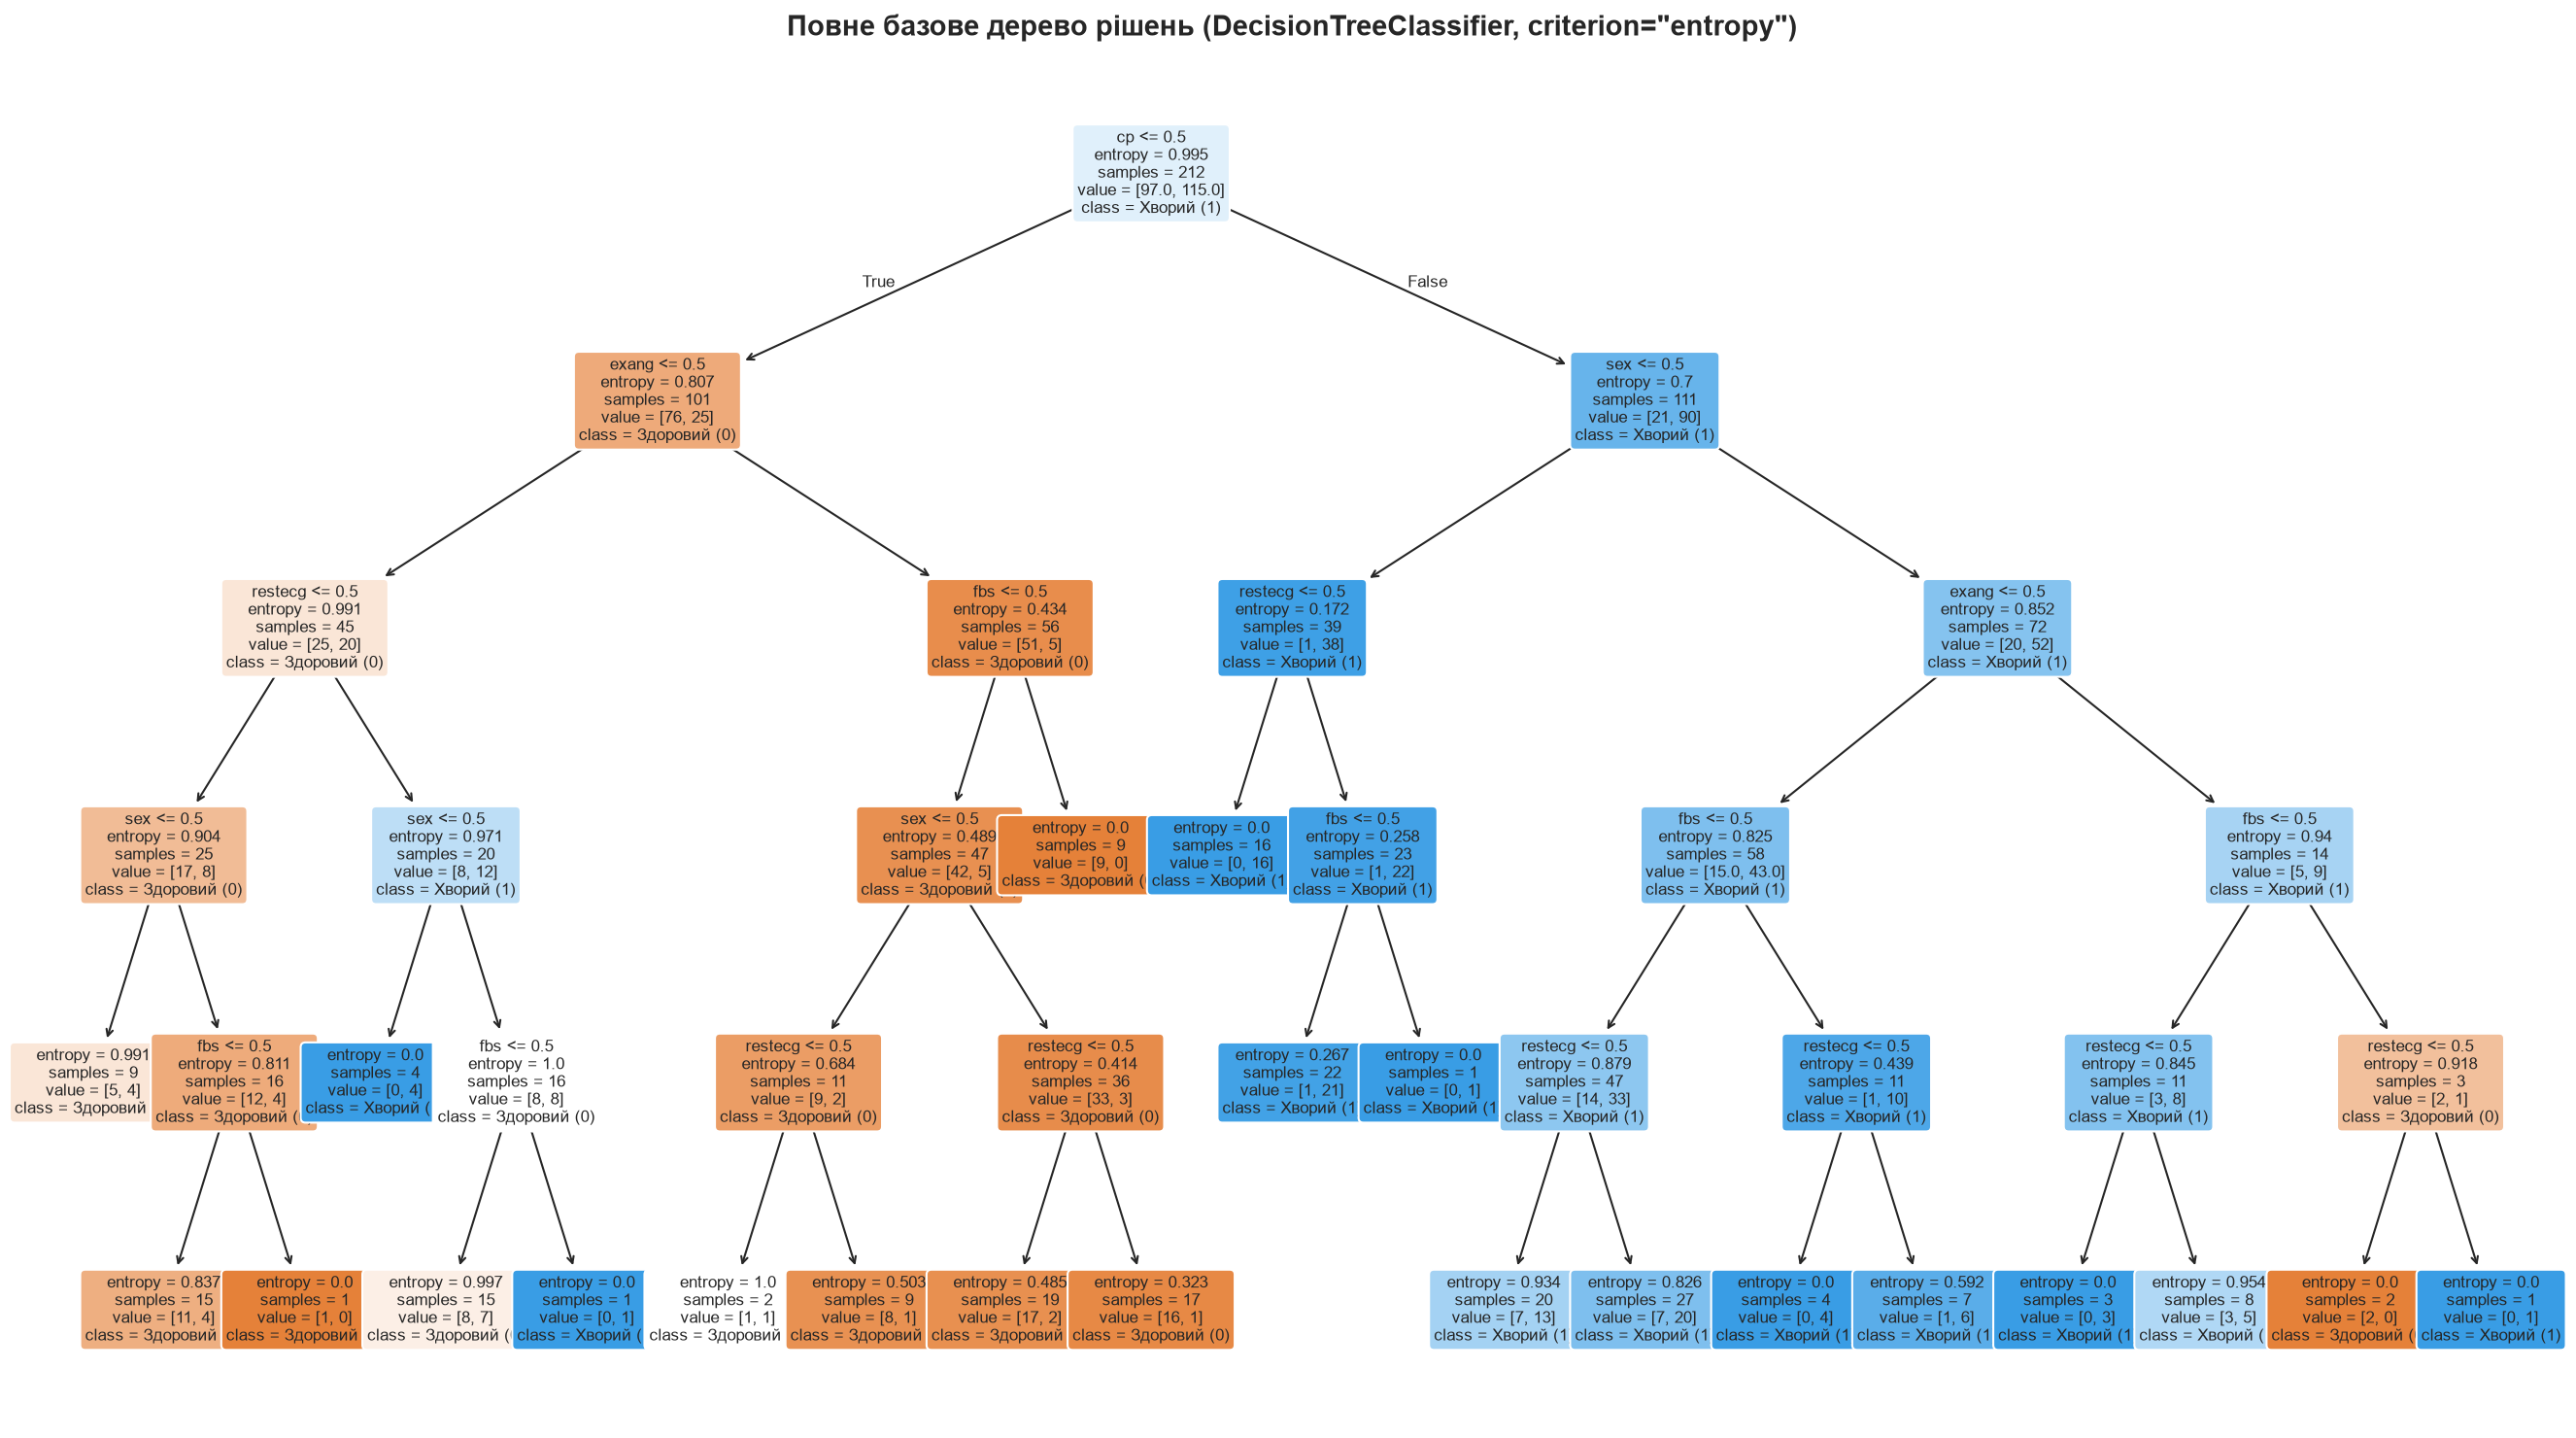

In [5]:
fig, ax = plt.subplots(figsize=(18, 10), dpi=150)
plot_tree(
    clf_full,
    feature_names=feature_cols,
    class_names=['Здоровий (0)', 'Хворий (1)'],
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
)
ax.set_title('Повне базове дерево рішень (DecisionTreeClassifier, criterion="entropy")', fontsize=14, pad=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 5. Підбір гіперпараметра регуляризації через 5-кратну крос-валідацію
Для уникнення перенавчання проводимо підбір параметра `min_samples_split` (мінімальна кількість зразків, необхідна для розбиття внутрішнього вузла) у діапазоні від 2 до 50 за допомогою 5-кратної крос-валідації (`cv=5`).

In [6]:
splits_range = np.arange(2, 51)
cv_errors = []
cv_accuracies = []

for s in splits_range:
    clf_cv = DecisionTreeClassifier(criterion='entropy', min_samples_split=s, random_state=42)
    scores = cross_val_score(clf_cv, X_train, y_train, cv=5, scoring='accuracy')
    cv_errors.append(1.0 - np.mean(scores))
    cv_accuracies.append(np.mean(scores))

best_idx = int(np.argmin(cv_errors))
optimal_min_samples_split = int(splits_range[best_idx])
min_cv_error = float(cv_errors[best_idx])
best_cv_accuracy = float(cv_accuracies[best_idx])

print(f'Оптимальне значення min_samples_split: {optimal_min_samples_split}')
print(f'Мінімальна помилка крос-валідації (CV Error): {min_cv_error:.4f} (Точність: {best_cv_accuracy:.4f})')

Оптимальне значення min_samples_split: 37
Мінімальна помилка крос-валідації (CV Error): 0.2166 (Точність: 0.7834)


Будуємо графік залежності середньої помилки крос-валідації від значення параметра `min_samples_split` із позначенням точки оптимуму.

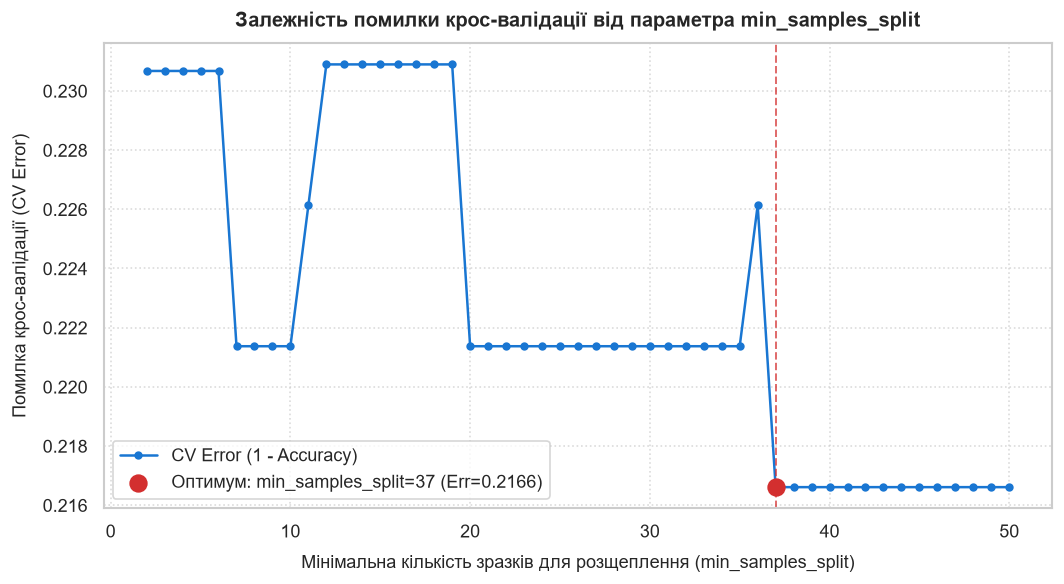

In [7]:
plt.figure(figsize=(9, 5), dpi=120)
plt.plot(splits_range, cv_errors, marker='o', markersize=4, linestyle='-', color='#1976d2', label='CV Error (1 - Accuracy)')
plt.scatter(optimal_min_samples_split, min_cv_error, color='#d32f2f', s=100, zorder=5, label=f'Оптимум: min_samples_split={optimal_min_samples_split} (Err={min_cv_error:.4f})')
plt.axvline(optimal_min_samples_split, color='#d32f2f', linestyle='--', linewidth=1.2, alpha=0.7)
plt.title('Залежність помилки крос-валідації від параметра min_samples_split', fontsize=12, pad=10, fontweight='bold')
plt.xlabel('Мінімальна кількість зразків для розщеплення (min_samples_split)', fontsize=11, labelpad=8)
plt.ylabel('Помилка крос-валідації (CV Error)', fontsize=11, labelpad=8)
plt.legend(frameon=True)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

### 6. Навчання та оцінка обрізаного дерева (Pruned Tree)
Навчаємо фінальну оптимізовану модель дерева з отриманим значенням `min_samples_split=37` та оцінюємо її метрики якості на відкладеній тестовій вибірці.

In [8]:
clf_pruned = DecisionTreeClassifier(
    criterion='entropy',
    min_samples_split=optimal_min_samples_split,
    random_state=42,
)
clf_pruned.fit(X_train, y_train)

y_pred_pruned = clf_pruned.predict(X_test)
acc_pruned = accuracy_score(y_test, y_pred_pruned)
prec_pruned = precision_score(y_test, y_pred_pruned)
rec_pruned = recall_score(y_test, y_pred_pruned)
f1_pruned = f1_score(y_test, y_pred_pruned)

print(f'Обрізане дерево: глибина = {clf_pruned.get_depth()}, кількість листків = {clf_pruned.get_n_leaves()}')
print(f'Метрики на тестовій вибірці:')
print(f'  Accuracy:  {acc_pruned:.4f}')
print(f'  Precision: {prec_pruned:.4f}')
print(f'  Recall:    {rec_pruned:.4f}')
print(f'  F1-Score:  {f1_pruned:.4f}')
print('\nДетальний звіт класифікації (Обрізане дерево):')
print(classification_report(y_test, y_pred_pruned, target_names=['Здоровий (0)', 'Хворий (1)']))

Обрізане дерево: глибина = 5, кількість листків = 11
Метрики на тестовій вибірці:
  Accuracy:  0.7033
  Precision: 0.6949
  Recall:    0.8200
  F1-Score:  0.7523

Детальний звіт класифікації (Обрізане дерево):
              precision    recall  f1-score   support

Здоровий (0)       0.72      0.56      0.63        41
  Хворий (1)       0.69      0.82      0.75        50

    accuracy                           0.70        91
   macro avg       0.71      0.69      0.69        91
weighted avg       0.71      0.70      0.70        91



Візуалізуємо редуковане дерево рішень.

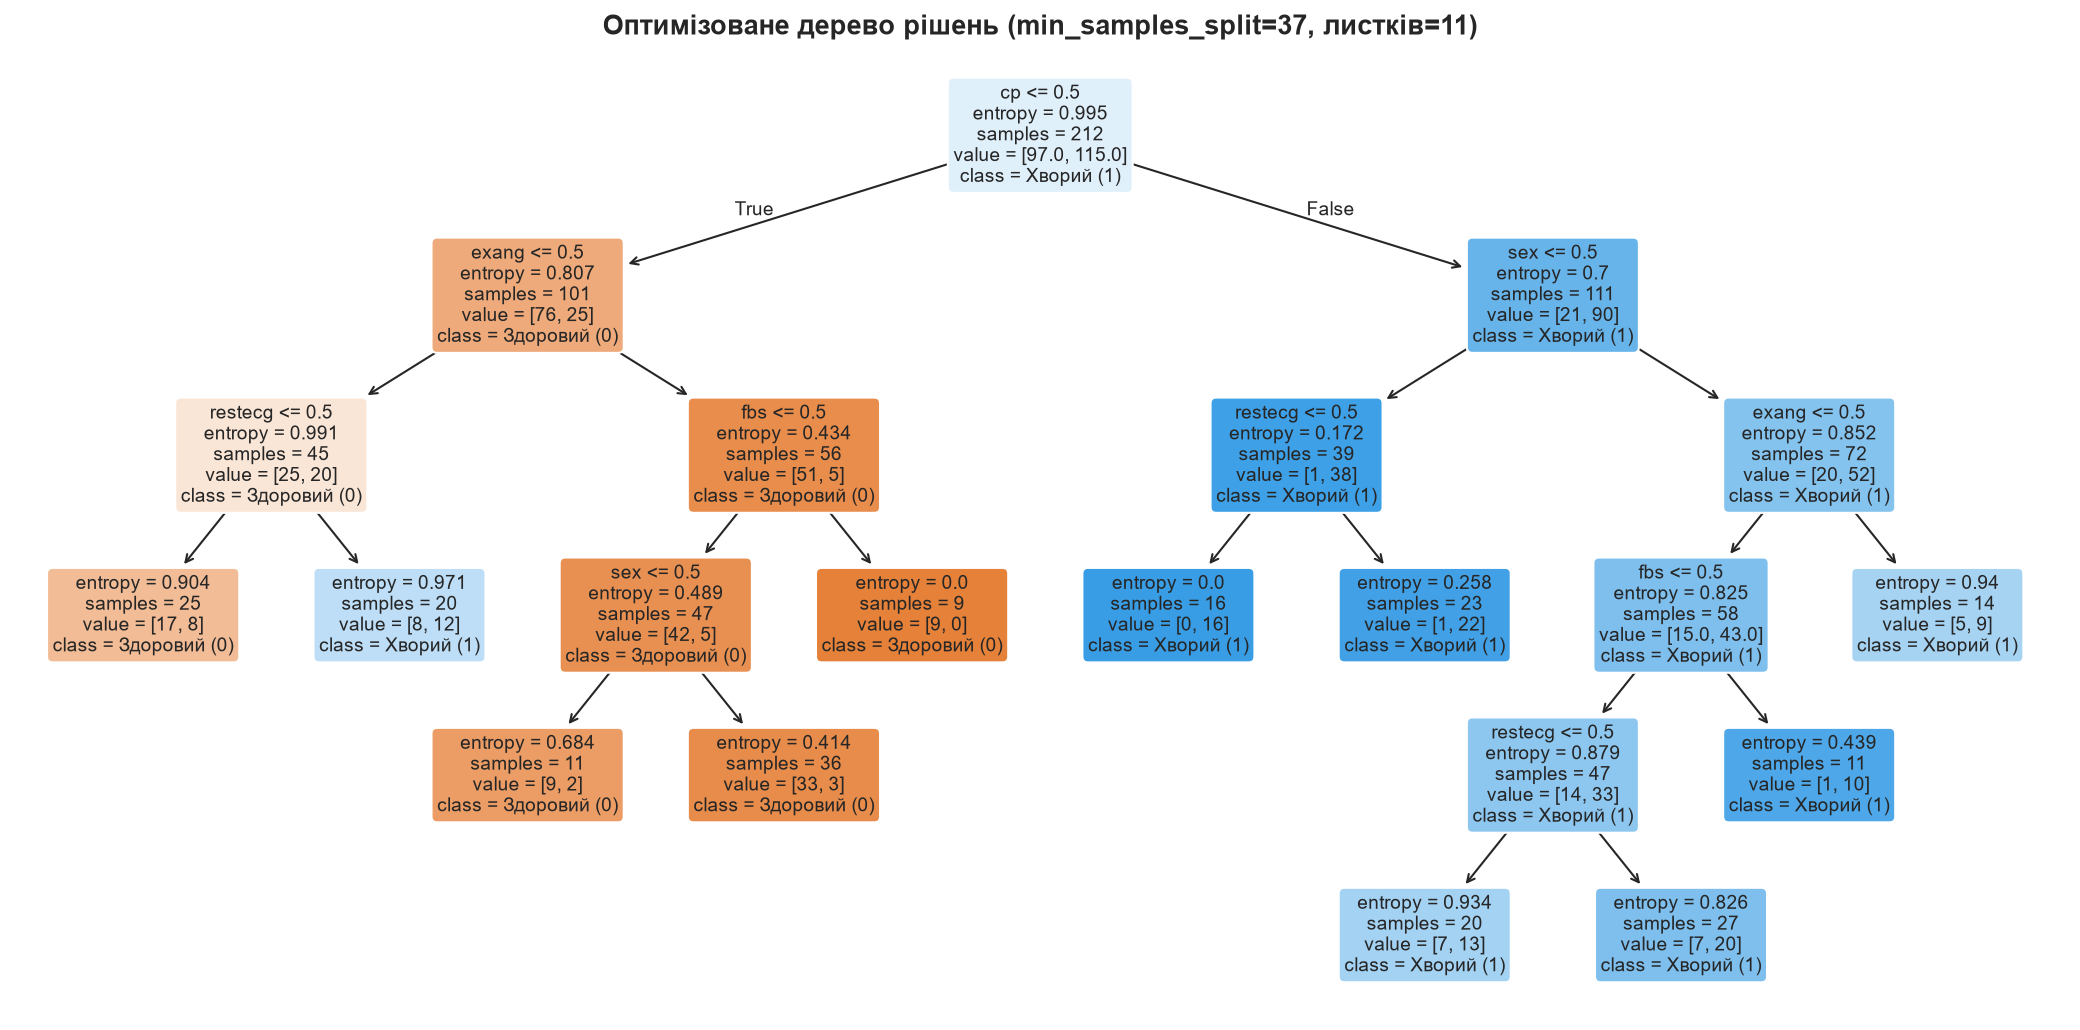

In [9]:
fig, ax = plt.subplots(figsize=(14, 7), dpi=150)
plot_tree(
    clf_pruned,
    feature_names=feature_cols,
    class_names=['Здоровий (0)', 'Хворий (1)'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
ax.set_title(f'Оптимізоване дерево рішень (min_samples_split={optimal_min_samples_split}, листків={clf_pruned.get_n_leaves()})', fontsize=13, pad=10, fontweight='bold')
plt.tight_layout()
plt.show()

### 7. Порівняння моделей: Матриці невідповідностей
Порівнюємо структури помилок базового та оптимізованого дерева за допомогою теплових карт матриць невідповідностей (`confusion_matrix`).

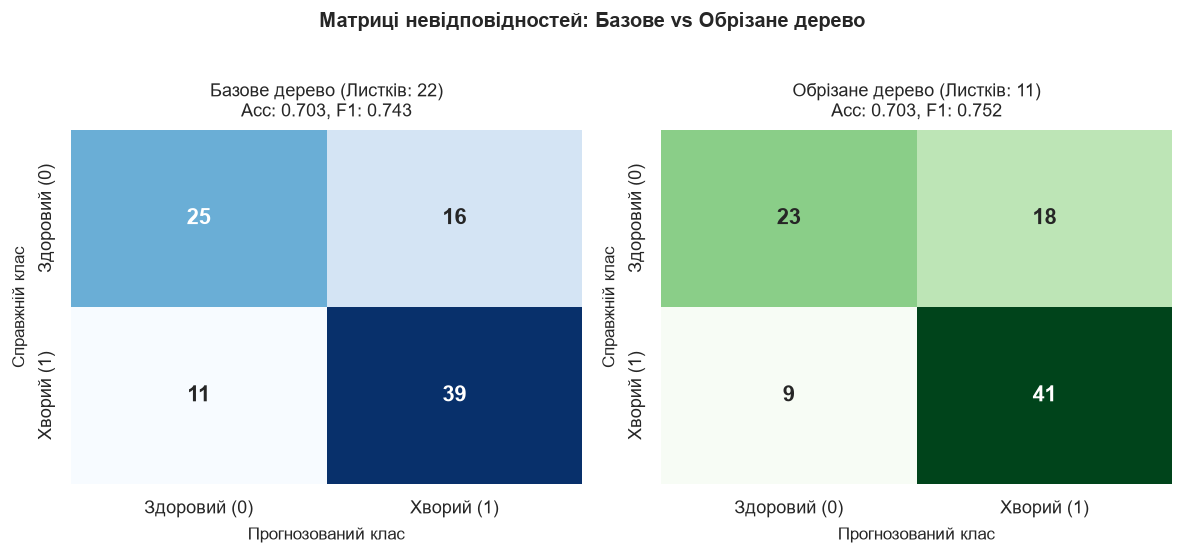

In [10]:
cm_full = confusion_matrix(y_test, y_pred_full)
cm_pruned = confusion_matrix(y_test, y_pred_pruned)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), dpi=120)

sns.heatmap(
    cm_full,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    ax=axes[0],
    xticklabels=['Здоровий (0)', 'Хворий (1)'],
    yticklabels=['Здоровий (0)', 'Хворий (1)'],
    annot_kws={'size': 13, 'weight': 'bold'},
)
axes[0].set_title(f'Базове дерево (Листків: {clf_full.get_n_leaves()})\nAcc: {acc_full:.3f}, F1: {f1_full:.3f}', fontsize=11, pad=8)
axes[0].set_xlabel('Прогнозований клас', fontsize=10, labelpad=6)
axes[0].set_ylabel('Справжній клас', fontsize=10, labelpad=6)

sns.heatmap(
    cm_pruned,
    annot=True,
    fmt='d',
    cmap='Greens',
    cbar=False,
    ax=axes[1],
    xticklabels=['Здоровий (0)', 'Хворий (1)'],
    yticklabels=['Здоровий (0)', 'Хворий (1)'],
    annot_kws={'size': 13, 'weight': 'bold'},
)
axes[1].set_title(f'Обрізане дерево (Листків: {clf_pruned.get_n_leaves()})\nAcc: {acc_pruned:.3f}, F1: {f1_pruned:.3f}', fontsize=11, pad=8)
axes[1].set_xlabel('Прогнозований клас', fontsize=10, labelpad=6)
axes[1].set_ylabel('Справжній клас', fontsize=10, labelpad=6)

plt.suptitle('Матриці невідповідностей: Базове vs Обрізане дерево', fontsize=12, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

### 8. Підсумкова порівняльна таблиця метрик
Зводимо показники обох моделей у табличний вигляд для наочного порівняння складності та точності.

In [11]:
comparison_df = pd.DataFrame({
    'Модель': ['Базове дерево (Full)', 'Обрізане дерево (Pruned)'],
    'min_samples_split': [2, optimal_min_samples_split],
    'Глибина дерева': [clf_full.get_depth(), clf_pruned.get_depth()],
    'Кількість листків': [clf_full.get_n_leaves(), clf_pruned.get_n_leaves()],
    'Accuracy': [acc_full, acc_pruned],
    'Precision': [prec_full, prec_pruned],
    'Recall': [rec_full, rec_pruned],
    'F1-Score': [f1_full, f1_pruned],
})
comparison_df

,Модель,min_samples_split,Глибина дерева,Кількість листків,Accuracy,Precision,Recall,F1-Score
0,Базове дерево (Full),2,5,22,0.703297,0.709091,0.78,0.742857
1,Обрізане дерево (Pruned),37,5,11,0.703297,0.694915,0.82,0.752294


### Висновки
1. Базова модель незрізаного дерева рішень формує надмірно складну структуру (22 листки), налаштовуючись на специфічні флуктуації навчальної вибірки.
2. Застосування 5-кратної крос-валідації дозволило встановити оптимальний поріг розщеплення `min_samples_split = 37`, що зменшило середню помилку класифікації до 0.2166 (точність 78.34%).
3. Обрізана модель скоротила кількість кінцевих листків у 2 рази (з 22 до 11) без погіршення загальної точності (`Accuracy = 0.7033`), при цьому повнота виявлення захворювання (`Recall`) зросла з 0.78 до 0.82, а значення гармонійного середнього `F1-Score` підвищилося до 0.7523.